In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from scipy.stats import ttest_ind, mannwhitneyu
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, RocCurveDisplay

In [35]:
df = pd.read_csv("data/aircraft_data.csv", sep=";", encoding="latin1")


dates = pd.to_datetime(df["first_flight"], format="%d.%m.%Y", errors="coerce")
df["age"] = ((pd.Timestamp("today") - dates).dt.days / 365.25)


df = df.query("0 <= age <= 50") # we only consider the aircraft that its age is smaller than 50 years
df = df[["age", "airline", "status"]].dropna()


status_clean = df["status"].astype(str).str.strip().str.lower()
is_active = status_clean == "active"
df["y"] = is_active.astype(int)


df_model = df[["age", "airline", "y"]].copy()
df_model = pd.get_dummies(df_model, columns=["airline"], drop_first=True)

X = df_model.drop(columns="y")
y = df_model["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]




In [6]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8584497838544285
ROC AUC: 0.9075601495305387


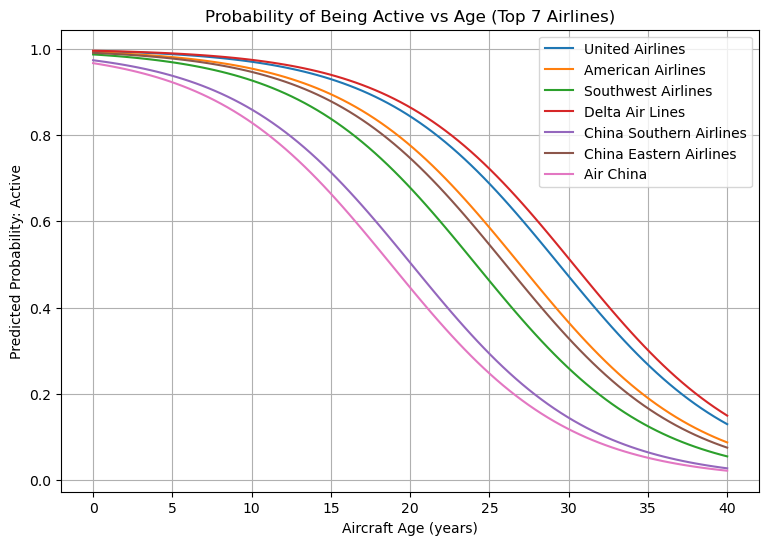

In [ ]:
ages = np.linspace(0, 40, 100)
top_airlines = df["airline"].value_counts().head(7).index

plt.figure(figsize=(9, 6))

for airline in top_airlines:
    grid = pd.DataFrame(0, index=np.arange(len(ages)), columns=X.columns)
    grid["age"] = ages
    col_name = f"airline_{airline}"
    if col_name in grid.columns:
        grid[col_name] = 1

    probs = model.predict_proba(grid)[:, 1]
    plt.plot(ages, probs, label=airline)

plt.xlabel("Aircraft Age (years)")
plt.ylabel("Predicted Probability: Active")
plt.title("Probability of Being Active vs Age (Top 7 Airlines)")
plt.legend()
plt.grid(True)
plt.show()

In [37]:
# Survival comparisons for:
# 1) A320 vs B737
# 2) A330 vs B777
# 3) B747 vs A380
# 4) B787 vs A350


df = pd.read_csv("data/aircraft_data.csv", sep=";", encoding="latin1")

dates = pd.to_datetime(df["first_flight"], dayfirst=True, errors="coerce")
df["age_years"] = (pd.Timestamp("today") - dates).dt.days / 365.25
df = df.query("0 <= age_years <= 50").copy()

status_clean = df["status"].str.strip().str.lower()
df["event"] = (status_clean != "active").astype(int)

df["model"] = df["model"].astype(str)

def compare_pair(pattern_a, pattern_b, label_a, label_b, title):
    kmf = KaplanMeierFitter()

    A = df[df["model"].str.contains(pattern_a, case=False, na=False)]
    B = df[df["model"].str.contains(pattern_b, case=False, na=False)]

    
    results = logrank_test(A["age_years"], B["age_years"],
                           event_observed_A=A["event"], event_observed_B=B["event"])
    
    pval = results.p_value

    
    fig, ax = plt.subplots(figsize=(9, 6))

    kmf.fit(A["age_years"], event_observed=A["event"], label=label_a)
    kmf.plot_survival_function(ci_show=False, ax=ax)
    kmf.fit(B["age_years"], event_observed=B["event"], label=label_b)
    kmf.plot_survival_function(ci_show=False, ax=ax)

    ax.set_title(title)
    ax.set_xlabel("Aircraft Age (years)")
    ax.set_ylabel("Probability of Remaining Active")
    ax.grid(True, alpha=0.4)
    ax.legend(title="Model")

   
    ax.text(0.98, 0.04, f"Log-rank p = {pval:.4g}",
            transform=ax.transAxes, ha="right", va="bottom",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),fontsize=11)

    plt.show()





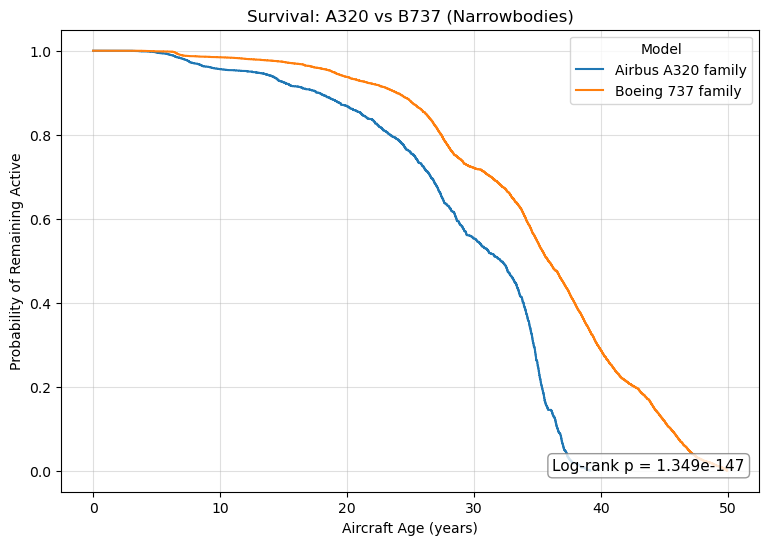

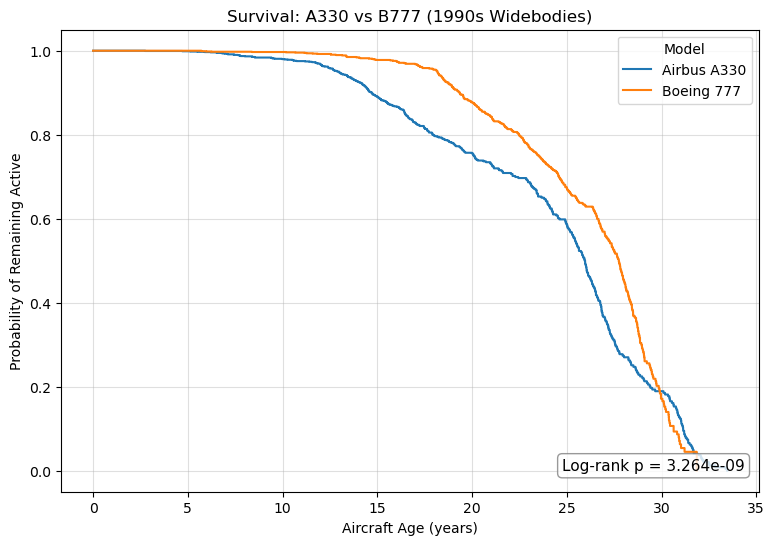

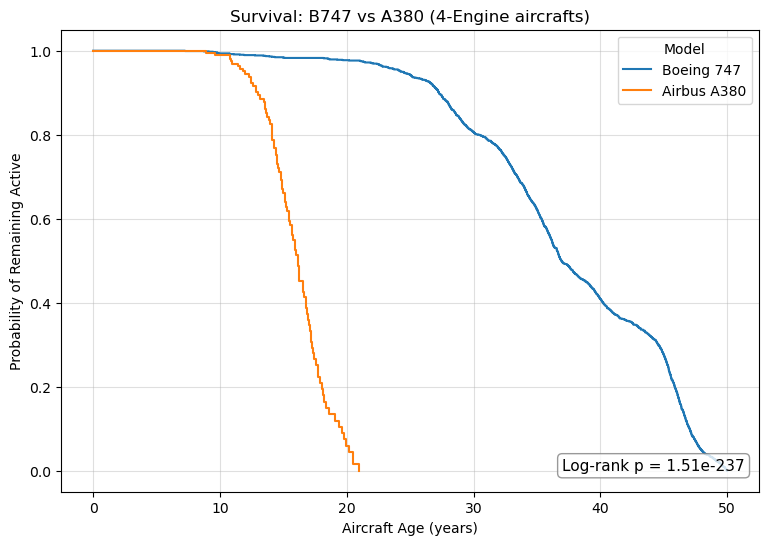

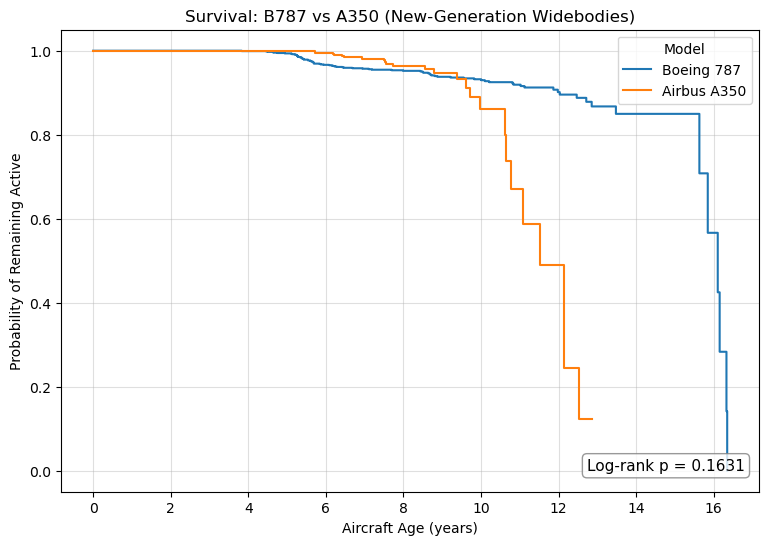

In [38]:
# ---------- 1) A320 vs B737 ----------
compare_pair(pattern_a=r"\bA320\b|airbus\s*a320",
             pattern_b=r"\bB737\b|boeing\s*737",
             label_a="Airbus A320 family",
             label_b="Boeing 737 family",
             title="Survival: A320 vs B737 (Narrowbodies)")

# ---------- 2) A330 vs B777 ----------
compare_pair(pattern_a=r"\bA330\b|airbus\s*a330",
             pattern_b=r"\bB777\b|boeing\s*777",
             label_a="Airbus A330",
             label_b="Boeing 777",
             title="Survival: A330 vs B777 (1990s Widebodies)")

# ---------- 3) B747 vs A380 ----------
compare_pair(pattern_a=r"\bB747\b|boeing\s*747",
             pattern_b=r"\bA380\b|airbus\s*a380",
             label_a="Boeing 747",
             label_b="Airbus A380",
             title="Survival: B747 vs A380 (4-Engine aircrafts)")

# ---------- 4) B787 vs A350 ----------
compare_pair(pattern_a=r"\bB787\b|boeing\s*787",
             pattern_b=r"\bA350\b|airbus\s*a350",
             label_a="Boeing 787",
             label_b="Airbus A350",
             title="Survival: B787 vs A350 (New-Generation Widebodies)")


Retirement age summary (years):
     group     n       mean     median        p25        p75
0     lcc   490  26.466334  26.819986  19.767283  36.082136
1  legacy  1583  30.845644  33.979466  24.722793  36.740589 

Welch t-test:  t=7.963,  p=6.808e-15
Mann–Whitney U: U=471898, p=3.866e-13


/var/folders/2s/pmq2df492vgg1l49kmbj_zhr0000gn/T/ipykernel_74224/353231180.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


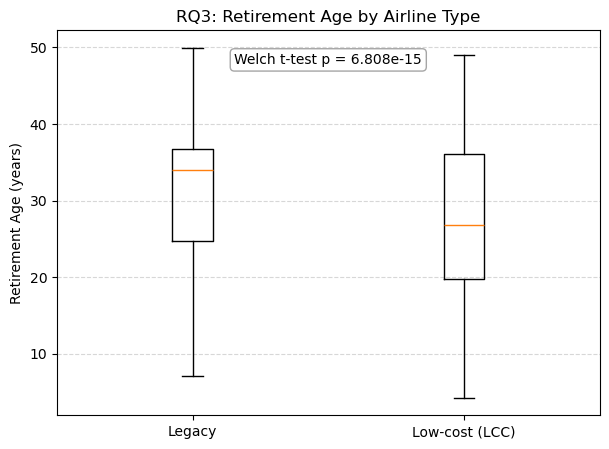

In [42]:

df = pd.read_csv("data/aircraft_data.csv", sep=";", encoding="latin1")


dates = pd.to_datetime(df["first_flight"], dayfirst=True, errors="coerce")
df["age_years"] = (pd.Timestamp("today") - dates).dt.days / 365.25
df = df.query("0 <= age_years <= 50").copy()

status_clean = df["status"].str.strip().str.lower()
df["event"] = (status_clean != "active").astype(int)

ret = df[df["event"] == 1].copy()


legacy_list = {
    "american airlines","delta air lines","united airlines","lufthansa",
    "air france","klm","british airways","qantas","japan airlines",
    "ana","cathay pacific","singapore airlines","air canada","iberia",
    "turkish airlines","qatar airways","emirates","etihad airways"}
lcc_list = {
    "ryanair","easyjet","southwest airlines","spirit airlines","frontier airlines",
    "jetblue","wizz air","norwegian","airasia","vueling","indigo",
    "peach","scoot","tigerair","gol","flydubai"}

def group_airline(name):
    
    s = str(name).strip().lower()
    if s in legacy_list:
        return "legacy" 
    
    elif s in lcc_list:
        return "lcc"      
    else:
        return None      

ret["group"] = ret["airline"].apply(group_airline)
ret = ret.dropna(subset=["group"])


summary = (ret.groupby("group")["age_years"]
           .agg(n="count", mean="mean", median="median",p25=lambda x: np.percentile(x,25), p75=lambda x: np.percentile(x,75)).reset_index())

print("Retirement age summary (years):\n", summary, "\n")

legacy_age = ret.loc[ret["group"]=="legacy","age_years"].to_numpy()
lcc_age    = ret.loc[ret["group"]=="lcc","age_years"].to_numpy()


t_res = ttest_ind(legacy_age, lcc_age, equal_var=False, nan_policy="omit")
u_res = mannwhitneyu(legacy_age, lcc_age, alternative="two-sided")

print(f"Welch t-test:  t={t_res.statistic:.3f},  p={t_res.pvalue:.4g}")
print(f"Mann–Whitney U: U={u_res.statistic:.0f}, p={u_res.pvalue:.4g}")

plt.figure(figsize=(7,5))
plt.boxplot(
    [legacy_age, lcc_age],
    labels=["Legacy", "Low-cost (LCC)"],
    showfliers=False
)
plt.ylabel("Retirement Age (years)")
plt.title("RQ3: Retirement Age by Airline Type")
plt.grid(True, axis="y", linestyle="--", alpha=0.5)


plt.text(
    1.5, max(np.concatenate([legacy_age, lcc_age])) * 0.95,
    f"Welch t-test p = {t_res.pvalue:.4g}",
    ha="center", va="bottom",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
)

plt.show()



Accuracy: 0.8964
ROC AUC: 0.947


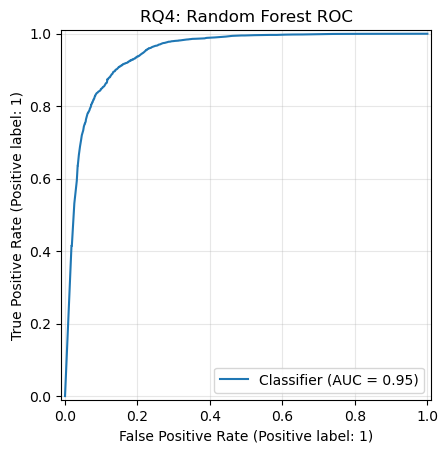

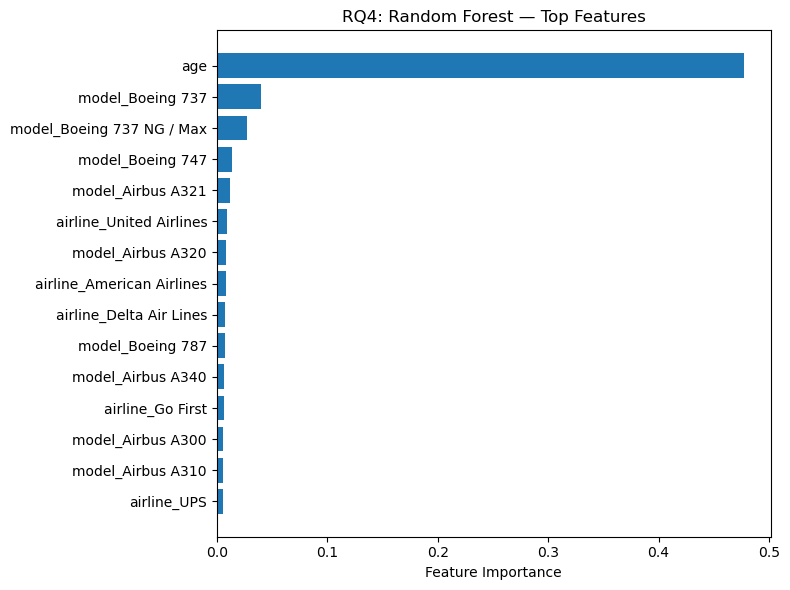

In [ ]:
df = pd.read_csv("data/aircraft_data.csv", sep=";", encoding="latin1")


dates = pd.to_datetime(df["first_flight"], dayfirst=True, errors="coerce")
df["age"] = (pd.Timestamp("today") - dates).dt.days / 365.25


df = df[["age", "airline", "model", "status"]].dropna()
df = df[(df["age"] >= 0) & (df["age"] <= 50)]


status_norm = df["status"].astype(str).str.strip().str.lower()
y = (status_norm == "active").astype(int)


X = df[["age", "airline", "model"]]


pre = ColumnTransformer(
    [("airline_ohe", OneHotEncoder(handle_unknown="ignore"), ["airline"]),
     ("model_ohe",   OneHotEncoder(handle_unknown="ignore"), ["model"])],
    remainder="passthrough"  
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1
)

pipe = Pipeline([("pre", pre), ("rf", rf)])


X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)


pipe.fit(X_tr, y_tr)

y_pred = pipe.predict(X_te)
y_prob = pipe.predict_proba(X_te)[:, 1]

print("Accuracy:", round(accuracy_score(y_te, y_pred), 4))
print("ROC AUC:", round(roc_auc_score(y_te, y_prob), 4))


RocCurveDisplay.from_predictions(y_te, y_prob)
plt.title("RQ4: Random Forest ROC")
plt.grid(True, alpha=0.3)
plt.show()


ohe_air = pipe.named_steps["pre"].named_transformers_["airline_ohe"]
ohe_mod = pipe.named_steps["pre"].named_transformers_["model_ohe"]
air_cols = list(ohe_air.get_feature_names_out(["airline"]))
mod_cols = list(ohe_mod.get_feature_names_out(["model"]))
feature_names = air_cols + mod_cols + ["age"]

importances = list(pipe.named_steps["rf"].feature_importances_)
pairs = list(zip(feature_names, importances))
pairs.sort(key=lambda x: x[1], reverse=True)
top = pairs[:15]

plt.figure(figsize=(8, 6))
plt.barh([name for name, _ in reversed(top)],
         [val for _, val in reversed(top)])
plt.xlabel("Feature Importance")
plt.title("RQ4: Random Forest — Top Features")
plt.tight_layout()
plt.show()
